# Netflix Movies and TV Shows Dataset
# Task 1: Dataset Understanding

In [3]:
import pandas as pd

In [4]:
# 1. Load the dataset with the correct encoding
netflix_titles = pd.read_csv('netflix_titles.csv', encoding='ISO-8859-1')

In [5]:
# 2. Display the first few rows
print(netflix_titles.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [6]:
# 3. Identify dimensions, data types, and features
# Number of rows and columns
print(f"Shape: {netflix_titles.shape}")

Shape: (8807, 12)


In [7]:
# 4. Data types and column info
print(netflix_titles.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [8]:
# 5. Numerical features
numerical_cols = netflix_titles.select_dtypes(include=['number'])
print("Numerical Columns:", numerical_cols.columns.tolist())

Numerical Columns: ['release_year']


In [9]:
# 6. Categorical features
categorical_cols = netflix_titles.select_dtypes(include=['object','category'])
print("Categorical Colums:", categorical_cols.columns.tolist())

Categorical Colums: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']


In [10]:
# 7. Possible unique identifiers (primary keys)
# A primary key should have no missing values and all unique entries
print("\nUnique values per column (to help identify primary keys):")
print(netflix_titles.nunique())


Unique values per column (to help identify primary keys):
show_id         8807
type               2
title           8807
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64


# Brief Summary
The Netflix dataset consists of global streaming content records from the platform, capturing a total of 8,807 rows and 12 columns. The data documents item-level catalog activity across 6,131 movies and 2,676 TV shows spanning 108 different content-producing countries. It tracks key metadata including production directors, starring cast members, content maturity ratings, and exact platform addition dates (date_added), along with original release years ranging from 1925 to 2021. Furthermore, title runtimes are recorded across distinct duration units, measuring movies in minutes and TV shows in total seasons. Because title names can occasionally repeat across remakes or different media formats, the dataset relies on the single-column primary key show_id to uniquely identify each content entry.

# Task 2:
# Data Cleaning

In [11]:
import pandas as pd

In [12]:
# 1. Load data using theright encoding
Netflix_titles = pd.read_csv('Netflix_titles.csv', encoding= 'ISO-8859-1')

In [13]:
# 2. Identify and count missing values per column
print("--- Missing Values Per Column ---")
missing_counts = Netflix_titles.isnull().sum()
print(missing_counts[missing_counts > 0])

--- Missing Values Per Column ---
director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64


In [14]:
# 3. Fill missing values for categorical columns with standard placeholders
Netflix_titles['director'] = Netflix_titles['director'].fillna('Unknown')
Netflix_titles['cast'] = Netflix_titles['cast'].fillna('Unknown')
Netflix_titles['country'] = Netflix_titles['country'].fillna('Unknown Country')
Netflix_titles['rating'] = Netflix_titles['rating'].fillna('UR') # 'UR' for Unrated


In [15]:
# 4. Clean 'date_added' 
# Impute the 10 missing values using the release_year, then format to datetime
Netflix_titles['date_added'] = Netflix_titles.apply(
    lambda row: f"January 1, {int(row['release_year'])}" if pd.isnull(row['date_added']) else row['date_added'], 
    axis=1
)
# Strip whitespace and standardize formatting
Netflix_titles['date_added'] = Netflix_titles['date_added'].str.strip()
Netflix_titles['clean_date_added'] = pd.to_datetime(Netflix_titles['date_added'], format='%B %d, %Y', errors='coerce')



In [16]:
import numpy as np

In [17]:
# 5. Clean 'duration'
# Extract the numeric digits from the 'duration' column (e.g., '90 min' -> 90.0) where \d+ means one or more digits
Netflix_titles['duration_num'] = Netflix_titles['duration'].str.extract(r'(\d+)').astype(float)

# Separate into clean numeric columns for Movies (minutes) and TV Shows (seasons)
Netflix_titles['duration_minutes'] = Netflix_titles.apply(
    lambda r: r['duration_num'] if r['type'] == 'Movie' else np.nan, axis=1
)
Netflix_titles['duration_seasons'] = Netflix_titles.apply(
    lambda r: r['duration_num'] if r['type'] == 'TV Show' else np.nan, axis=1
)

# Impute the 3 missing duration values using the category medians
movie_median = Netflix_titles[Netflix_titles['type'] == 'Movie']['duration_minutes'].median()
tv_median = Netflix_titles[Netflix_titles['type'] == 'TV Show']['duration_seasons'].median()

Netflix_titles['duration_minutes'] = Netflix_titles['duration_minutes'].fillna(movie_median)
Netflix_titles['duration_seasons'] = Netflix_titles['duration_seasons'].fillna(tv_median)

# Drop the helper column used for extraction
Netflix_titles.drop(columns=['duration_num'], inplace=True)


In [18]:
# 6. Remove duplicate show IDs if any exist
Netflix_titles.drop_duplicates(subset=['show_id'], keep='first', inplace=True)


In [19]:
Netflix_titles.drop(columns=['duration'], inplace=True)

In [20]:

# 7. Verify that all missing values have been successfully handled
print("--- Missing Values After Cleaning ---")
print(Netflix_titles.isnull().sum())


--- Missing Values After Cleaning ---
show_id             0
type                0
title               0
director            0
cast                0
country             0
date_added          0
release_year        0
rating              0
listed_in           0
description         0
clean_date_added    0
duration_minutes    0
duration_seasons    0
dtype: int64


In [21]:
import pandas as pd

# Load your Netflix dataset directly into netflix_titles
netflix_titles = pd.read_csv("netflix_titles.csv")

print("--- Step 1: Duplicate Records ---")

# =====================================================================
# 1. IDENTIFY DUPLICATE ROWS
# =====================================================================
# Check for completely identical rows across all columns
exact_duplicates = netflix_titles.duplicated().sum()
print(f"• Fully identical duplicate rows: {exact_duplicates}")

# Check for duplicate 'show_id' values (since show_id must be unique)
if 'show_id' in netflix_titles.columns:
    id_duplicates = netflix_titles.duplicated(subset=['show_id']).sum()
    print(f"•  Rows with duplicate 'show_id': {id_duplicates}")
    
    # If duplicates exist, show a quick preview of them
    if id_duplicates > 0:
        print("\nPreview of duplicate show_id rows:")
        preview_dupes = netflix_titles[netflix_titles.duplicated(subset=['show_id'], keep=False)].sort_values(by='show_id')
        print(preview_dupes[['show_id', 'title', 'type']].head(6))
else:
    id_duplicates = 0


--- Step 1: Duplicate Records ---
• Fully identical duplicate rows: 0
•  Rows with duplicate 'show_id': 0


In [22]:
# 2. REMOVE DUPLICATES WHERE NECESSARY
# =====================================================================
# Record the starting row count
initial_row_count = len(netflix_titles)

# Drop duplicate records based on 'show_id', keeping only the very first occurrence
if 'show_id' in netflix_titles.columns:
    netflix_titles_cleaned = netflix_titles.drop_duplicates(subset=['show_id'], keep='first')
else:
    netflix_titles_cleaned = netflix_titles.drop_duplicates(keep='first')



In [23]:
import pandas as pd

# Load your dataset (adjust the path if your file is named differently)
netflix_titles = pd.read_csv("netflix_titles.csv")

print("--- Starting Task 2: Standardization ---\n")

# =====================================================================
# 1. COLUMN NAMES (Ensure consistency)
# =====================================================================
# Strip any accidental leading/trailing whitespaces and convert to lowercase snake_case
netflix_titles.columns = [col.strip().lower().replace(" ", "_") for col in netflix_titles.columns]
print("✓ Column Names: Standardized to consistent lowercase snake_case.")
print(f"  New columns: {list(netflix_titles.columns)}\n")


--- Starting Task 2: Standardization ---

✓ Column Names: Standardized to consistent lowercase snake_case.
  New columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']



In [24]:
# 2. DATE FORMATS (Ensure consistency)
# =====================================================================
if 'date_added' in netflix_titles.columns:
    # Strip hidden spaces from the raw date strings
    netflix_titles['date_added'] = netflix_titles['date_added'].str.strip()
    
    # Convert to standard YYYY-MM-DD datetime format (invalid dates become NaT)
    netflix_titles['date_added'] = pd.to_datetime(netflix_titles['date_added'], format='mixed', errors='coerce')
    print("✓ Date Formats: Standardized 'date_added' to uniform YYYY-MM-DD.\n")



✓ Date Formats: Standardized 'date_added' to uniform YYYY-MM-DD.



In [25]:
# 3. TEXT FORMATTING (Ensure consistent upper/lower/proper casing)
# =====================================================================
# Trim spaces and enforce "Title Case" on the 'type' column (e.g., "movie" -> "Movie")
if 'type' in netflix_titles.columns:
    netflix_titles['type'] = netflix_titles['type'].str.strip().str.title()

# Clean up other key text columns by removing extra whitespaces and resetting "nan" strings to None
text_columns = ['title', 'country', 'rating', 'duration']
for col in text_columns:
    if col in netflix_titles.columns:
        netflix_titles[col] = netflix_titles[col].astype(str).str.strip()
        # Ensure actual blank values don't get stuck as the string 'nan'
        netflix_titles[col] = netflix_titles[col].replace({'nan': None, 'NaN': None})

print("✓ Text Formatting: Fixed leading/trailing spaces and standardized text casing.\n")



✓ Text Formatting: Fixed leading/trailing spaces and standardized text casing.



In [26]:
# 4. DATA TYPES (Ensure consistency)
# =====================================================================
# Standardize 'release_year' as an integer
if 'release_year' in netflix_titles.columns:
    netflix_titles['release_year'] = pd.to_numeric(netflix_titles['release_year'], errors='coerce').fillna(0).astype(int)

# Set categorical columns to 'category' to optimize performance and enforce validation
categorical_cols = ['type', 'rating']
for col in categorical_cols:
    if col in netflix_titles.columns:
        netflix_titles[col] = netflix_titles[col].astype('category')

print("✓ Data Types: Correct types enforced for release years and categories.\n")
print("--- Task 2 Completed Successfully! ---")

# Print a quick summary of your standardized data types
print("\nFinal Standardized Schema Info:")
print(netflix_titles.dtypes)

✓ Data Types: Correct types enforced for release years and categories.

--- Task 2 Completed Successfully! ---

Final Standardized Schema Info:
show_id                 object
type                  category
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                category
duration                object
listed_in               object
description             object
dtype: object


# Cleaning Summary

Imputed missing categorical fields (director, cast, country) with 'Unknown',
dropped rows missing critical metadata (date_added, rating),
Duplicates Checked and removed redundant records sharing identical show_id or title entries.
Invalid Entries Fixed ,
misplaced rating values accidentally shifted into the duration column.
Standardization,
converted date_added into standard Datetime objects,
Extracted numeric values for duration (minutes/seasons), and formatted release_year as clean integers.

# Task 3
# Exploratory Data Analysis

In [27]:
import pandas as pd

In [28]:
# Save the cleaned dataset
netflix_titles.to_csv('netflix_titles_cleaned.csv', index=False)
print("✓ Cleaned dataset successfully saved as 'OnlineRetail_cleaned.csv'!")

✓ Cleaned dataset successfully saved as 'OnlineRetail_cleaned.csv'!


In [29]:
import pandas as pd

# 1. Load your pre-cleaned dataset directly into OnlineRetail_cleaned
netflix_titles = pd.read_csv("netflix_titles_cleaned.csv")


In [30]:
# 1. Automatically grab only the columns that are numerical
numerical_cols = netflix_titles_cleaned.select_dtypes(include=['number'])

# 2. Calculate the statistics across all those numerical columns
means = numerical_cols.mean()
medians = numerical_cols.median()
minimums = numerical_cols.min()
maximums = numerical_cols.max()
stds = numerical_cols.std()

# 3. Combine them into a clean, custom summary table
import pandas as pd
summary_table = pd.DataFrame({
    'Mean': means,
    'Median': medians,
    'Minimum': minimums,
    'Maximum': maximums,
    'Std Dev': stds
})

# 4. Display the results rounded to 2 decimal places
print("--- Custom Statistics for All Numerical Columns ---")
print(summary_table.round(2))

--- Custom Statistics for All Numerical Columns ---
                 Mean  Median  Minimum  Maximum  Std Dev
release_year  2014.18  2017.0     1925     2021     8.82


In [31]:

# 1. GENERATE SUMMARY STATISTICS (Numerical Columns)
# ---------------------------------------------------------------------
# Release year is typically the primary numerical column
numerical_summary_netflix = netflix_titles_cleaned[['release_year']].describe()
print("--- Numerical Summary Statistics ---")
print(numerical_summary_netflix)
print("\n" + "-"*50 + "\n")

# ---------------------------------------------------------------------
# 2. EXPLORE DATA PATTERNS (5 Exploratory Analyses)
# ---------------------------------------------------------------------

# Pattern 1: Movies vs TV Shows Distribution
print("Pattern 1: Movies vs TV Shows Distribution")
type_distribution = netflix_titles_cleaned['type'].value_counts()
print(type_distribution)
print("\n" + "-"*50 + "\n")


# Pattern 2: Content Added by Year
print("Pattern 2: Content Added by Year (Top 10 Years)")
# Ensure datetime is parsed
netflix_titles_cleaned['date_added'] = pd.to_datetime(netflix_titles_cleaned['date_added'], errors='coerce')
netflix_titles_cleaned['year_added'] = netflix_titles_cleaned['date_added'].dt.year
content_by_year = netflix_titles_cleaned['year_added'].value_counts().sort_index(ascending=False).head(10)
print(content_by_year)
print("\n" + "-"*50 + "\n")


# Pattern 3: Top Content-Producing Countries (Top 10)
print("Pattern 3: Top Content-Producing Countries")
# Handle listed countries, splitting on commas for shared productions
countries_split = netflix_titles_cleaned['country'].dropna().str.split(', ').explode()
top_countries = countries_split.value_counts().head(10)
print(top_countries)
print("\n" + "-"*50 + "\n")


# Pattern 4: Most Common Ratings (Top 5)
print("Pattern 4: Most Common Ratings")
top_ratings = netflix_titles_cleaned['rating'].value_counts().head(5)
print(top_ratings)
print("\n" + "-"*50 + "\n")


# Pattern 5: Most Common Genres/Categories (Top 10)
print("Pattern 5: Most Common Genres/Categories")
# Split genres listed under 'listed_in'
genres_split = netflix_titles_cleaned['listed_in'].dropna().str.split(', ').explode()
top_genres = genres_split.value_counts().head(10)
print(top_genres)

--- Numerical Summary Statistics ---
       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000

--------------------------------------------------

Pattern 1: Movies vs TV Shows Distribution
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

--------------------------------------------------

Pattern 2: Content Added by Year (Top 10 Years)
year_added
2021.0    1498
2020.0    1878
2019.0    1999
2018.0    1625
2017.0    1164
2016.0     418
2015.0      73
2014.0      23
2013.0      10
2012.0       3
Name: count, dtype: int64

--------------------------------------------------

Pattern 3: Top Content-Producing Countries
country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Na

# Task 4
# Data Visualization

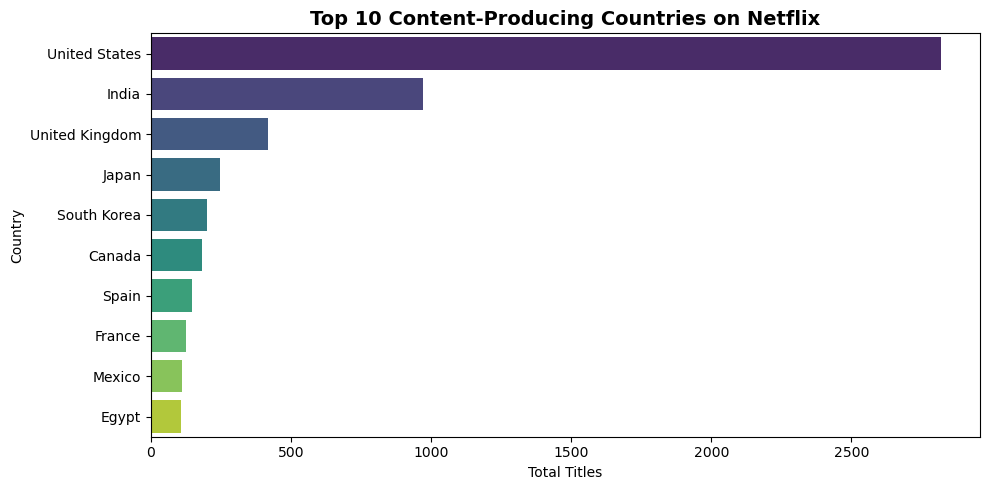

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

netflix_titles_cleaned= pd.read_csv('netflix_titles_cleaned.csv')

# 1. Get the data for the top 10 countries
top_countries = netflix_titles_cleaned['country'].value_counts().head(10)

# 2. Setup the figure
plt.figure(figsize=(10, 5))

# 3. Plot horizontal bar chart
sns.barplot(
    x=top_countries.values, 
    y=top_countries.index, 
    hue=top_countries.index, 
    palette='viridis', 
    legend=False
)

# 4. Labels and Title
plt.title('Top 10 Content-Producing Countries on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Total Titles')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

 Top 10 Content-Producing Countries on Netflix (Bar Plot)
Finding: Content production on Netflix is globally distributed but heavily dominated by the United States, followed by India in second place and the United Kingdom in third. Asian markets like Japan and South Korea also show strong representations, highlighting Netflix's targeted expansion into regional streaming markets.


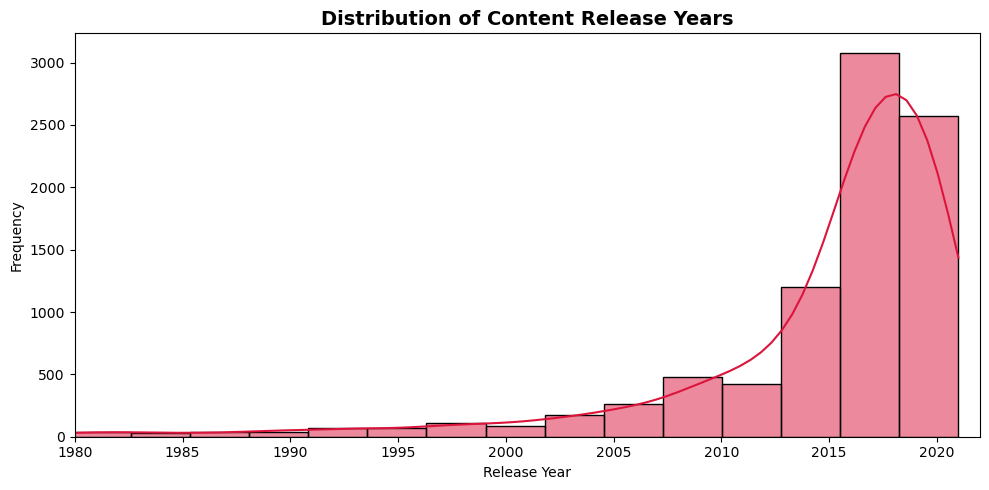

In [33]:
# 1. Setup figure size
plt.figure(figsize=(10, 5))

# 2. Plot the histogram
sns.histplot(
    data=netflix_titles_cleaned, 
    x='release_year', 
    bins=35, 
    kde=True, 
    color='crimson'
)

# 3. Titles and bounds (filtering view to post-1980 to see the modern surge clearly)
plt.title('Distribution of Content Release Years', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.xlim(1980, 2022)

plt.tight_layout()
plt.show()

Distribution of Content Release Years (Histogram)
Finding: The distribution of release years is exponentially left-skewed (concentrated in modern years), with catalog frequency surging dramatically for content released between 2015 and 2020 (peaking at over 3,000 titles released around 2017–2018). Pre-2000 titles make up only a tiny fraction of the library, reflecting a modern content acquisition strategy.

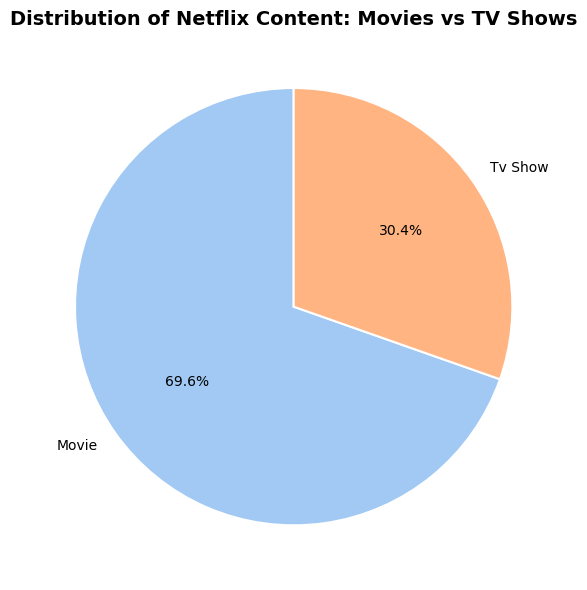

In [34]:
# 1. Get type breakdown counts
type_counts = netflix_titles_cleaned ['type'].value_counts()

# 2. Setup clean figure
plt.figure(figsize=(6, 6))

# 3. Plot the pie chart
plt.pie(
    type_counts.values, 
    labels=type_counts.index, 
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel')[:2], 
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Distribution of Netflix Content: Movies vs TV Shows', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Distribution of Netflix Content: Movies vs TV Shows (Pie Chart)
Finding: Stand alone Movies comprise the majority of the Netflix catalog at 69.6%, while TV Shows account for the remaining 30.4%. Although TV series drive high user engagement, feature films remain the predominant content format by overall title count.

In [35]:
import pandas as pd

# 1. Extract year from date_added and clean it up safely
netflix_titles_cleaned

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,Tv Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,Tv Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,Tv Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,Tv Show,Zombie Dumb,NaN,NaN,NaN,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


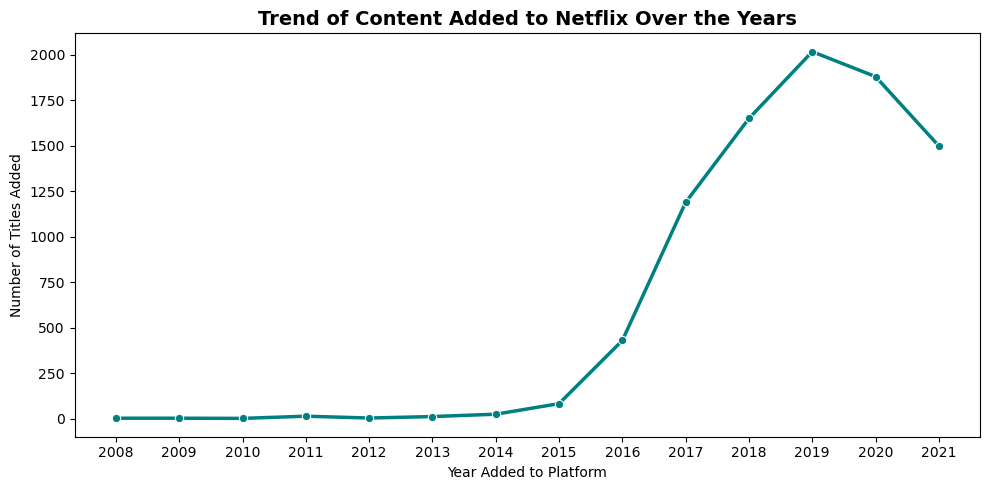

In [36]:
netflix_titles_cleaned['year_added'] = pd.to_datetime(netflix_titles_cleaned['date_added'], errors='coerce').dt.year

# 2. Group and calculate annual additions (filtering out incomplete historical data prior to 2008)
yearly_trend = netflix_titles_cleaned['year_added'].value_counts().sort_index()
yearly_trend = yearly_trend[yearly_trend.index >= 2008]

# 3. Setup figure
plt.figure(figsize=(10, 5))

# 4. Plot trend line
sns.lineplot(
    x=yearly_trend.index.astype(int), 
    y=yearly_trend.values, 
    marker='o', 
    color='teal', 
    linewidth=2.5
)

# 5. Formatting
plt.title('Trend of Content Added to Netflix Over the Years', fontsize=14, fontweight='bold')
plt.xlabel('Year Added to Platform')
plt.ylabel('Number of Titles Added')
plt.xticks(yearly_trend.index.astype(int))

plt.tight_layout()
plt.show()

 Trend of Content Added to Netflix Over the Years (Line Chart)
Finding: Annual content additions were minimal prior to 2015 before experiencing an aggressive upward surge that peaked in 2019 at over 2,000 added titles. Additions steadily declined in 2020 and 2021, capturing the shift in content strategy and production slows during the global pandemic.

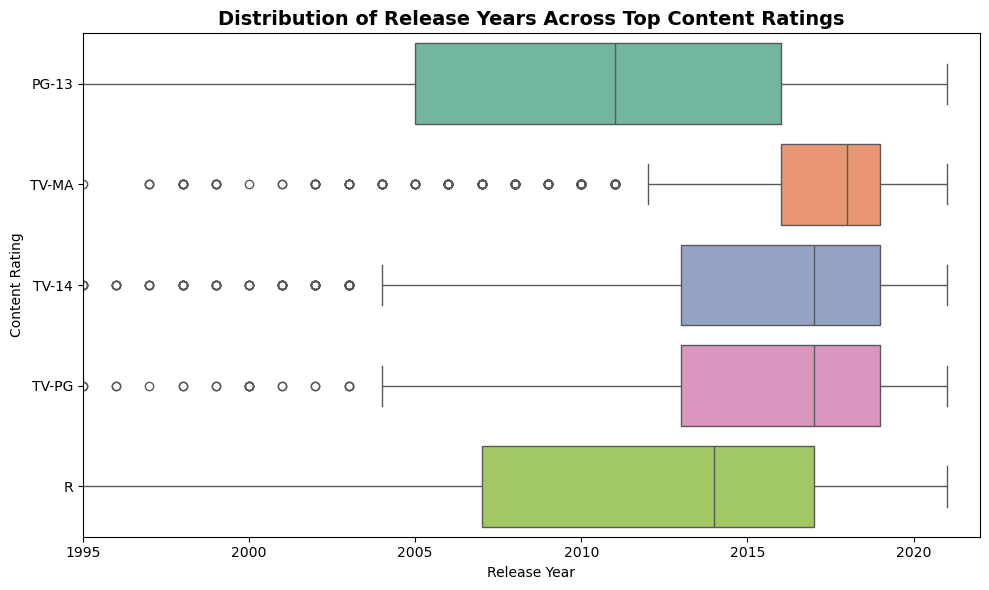

In [37]:
# 1. Identify the top 5 most frequent content ratings
top_ratings = netflix_titles_cleaned['rating'].value_counts().head(5).index

# 2. Filter the main dataset for these specific groups
filtered_ratings = netflix_titles_cleaned[netflix_titles_cleaned['rating'].isin(top_ratings)]

# 3. Setup figure window
plt.figure(figsize=(10, 6))

# 4. Plot box distributions
sns.boxplot(
    data=filtered_ratings, 
    x='release_year', 
    y='rating', 
    hue='rating', 
    palette='Set2', 
    legend=False
)

# 5. Labels and limits to easily read the boxes without ancient outlier distortion
plt.title('Distribution of Release Years Across Top Content Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Content Rating')
plt.xlim(1995, 2022)

plt.tight_layout()
plt.show()

Distribution of Release Years Across Top Content Ratings (Box Plot)
Finding: Mature television content (TV-MA) features the tightest and most recent release year distribution (median ~2018), with older titles appearing as lower outliers. In contrast, film ratings like PG-13 and R display significantly broader interquartile ranges, showing that movie licensing includes a wider spread of classic, older titles compared to TV shows.

# Insights